# Porownanie kalibracji fisheye

Notatnik przeniesiony z `compare_fisheye_calibrations.py`.

Wymagane sa zmienne przygotowane w `detect_chessboard_corners.ipynb` (np. `network_input`, `camera_matrix`, `distortion_coefficients`, `object_points_all`, `image_points_all`, `image_paths_for_calibration`, `image_size_calibration`).

In [1]:
import pathlib
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import yaml
from IPython.display import display

sys.modules.setdefault('pathlib._local', pathlib)

PROJECT_ROOT = pathlib.Path('/home/dbabiarczyk/studia/semestr10/camera_calibration')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.networks_tool.models import FisheyeCornerGRUSequenceCalibrationNet

# Samodzielne przygotowanie danych: wczytanie punktow i kalibracja OpenCV.
POINTS_DIR = PROJECT_ROOT / 'data/xfronter_calibration/characteristic_point'
point_files = sorted(
    path for path in POINTS_DIR.glob('*.yaml') if not path.name.startswith('camera_calibration')
)
if not point_files:
    raise FileNotFoundError(f'Brak plikow YAML z punktami w: {POINTS_DIR}')

object_points_all: list[np.ndarray] = []
image_points_all: list[np.ndarray] = []
view_names: list[str] = []
image_paths_for_calibration: list[pathlib.Path] = []
image_size_calibration: tuple[int, int] | None = None

for point_file in point_files:
    with point_file.open('r', encoding='utf-8') as file:
        point_data = yaml.safe_load(file)

    required_keys = {'image_points_px', 'object_points_mm', 'image_width_px', 'image_height_px'}
    missing_keys = required_keys.difference(point_data)
    if missing_keys:
        raise ValueError(f'{point_file.name}: brak pol {sorted(missing_keys)}')

    image_points_view = np.asarray(point_data['image_points_px'], dtype=np.float64).reshape(-1, 1, 2)
    object_points_view = np.asarray(point_data['object_points_mm'], dtype=np.float64).reshape(-1, 1, 3)
    if len(image_points_view) != len(object_points_view) or len(image_points_view) < 4:
        raise ValueError(
            f'{point_file.name}: niepoprawna liczba punktow '
            f'2D={len(image_points_view)}, 3D={len(object_points_view)}'
        )

    current_size = (int(point_data['image_width_px']), int(point_data['image_height_px']))
    if image_size_calibration is None:
        image_size_calibration = current_size
    elif current_size != image_size_calibration:
        raise ValueError(
            f'{point_file.name}: rozmiar {current_size} rozni sie od {image_size_calibration}'
        )

    object_points_all.append(object_points_view)
    image_points_all.append(image_points_view)
    view_names.append(str(point_data.get('image_name', point_file.stem)))

    raw_path = str(point_data.get('image_path', '')).strip()
    image_path = pathlib.Path(raw_path) if raw_path else pathlib.Path()
    if not image_path.is_file():
        candidate = point_file.parent / f"{point_file.stem}_correct.png"
        image_path = candidate if candidate.is_file() else image_path
    image_paths_for_calibration.append(image_path)

assert image_size_calibration is not None
if len(object_points_all) < 3:
    raise ValueError('Kalibracja wymaga punktow z co najmniej 3 roznych obrazow.')

camera_matrix = np.zeros((3, 3), dtype=np.float64)
distortion_coefficients = np.zeros((4, 1), dtype=np.float64)
calibration_flags = cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC | cv2.fisheye.CALIB_FIX_SKEW
calibration_criteria = (
    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
    100,
    1e-9,
)

rms_opencv, camera_matrix, distortion_coefficients, rotation_vectors, translation_vectors = cv2.fisheye.calibrate(
    object_points_all,
    image_points_all,
    image_size_calibration,
    camera_matrix,
    distortion_coefficients,
    flags=calibration_flags,
    criteria=calibration_criteria,
)

global_reprojection_rmse = float(rms_opencv)

# Przygotowanie wejscia sieci w identycznym formacie jak podczas treningu.
checkpoint = torch.load(
    PROJECT_ROOT / 'outputs/calibration_net_fisheye/best_model.pth',
    map_location='cpu',
    weights_only=False,
)
network_config = checkpoint['config']
if len(image_points_all) != network_config.sequence_length:
    raise ValueError(
        f'Siec wymaga {network_config.sequence_length} klatek, a wczytano {len(image_points_all)}.'
    )

sequence_features = []
for image_points_view in image_points_all:
    pixel_points = image_points_view.reshape(-1, 2).astype(np.float32)
    centered_points = pixel_points - pixel_points.mean(axis=0, keepdims=True)
    coordinate_scale = np.maximum(centered_points.std(axis=0, keepdims=True), 1e-6)
    sequence_features.append(
        np.concatenate([pixel_points, centered_points / coordinate_scale], axis=1)
    )

network_input = torch.from_numpy(np.stack(sequence_features)[None]).to(torch.float32)

print(f'Wczytano {len(point_files)} plikow YAML z punktami.')
print(f'Rozdzielczosc kalibracji: {image_size_calibration}')
print(f'Wejscie sieci: {tuple(network_input.shape)}')

Wczytano 10 plikow YAML z punktami.
Rozdzielczosc kalibracji: (1920, 1080)
Wejscie sieci: (1, 10, 81, 4)


In [2]:
MODEL_CHECKPOINTS = {
    'Siec GRU': PROJECT_ROOT / 'outputs/calibration_net_fisheye/best_model.pth',
    'Siec LSTM': PROJECT_ROOT / 'outputs/calibration_net_fisheye_lstm/best_model.pth',
    'Siec SSM': PROJECT_ROOT / 'outputs/calibration_net_fisheye_ssm/best_model.pth',
}


class FrameEncoder(nn.Sequential):
    def __init__(self, points=81):
        super().__init__(
            nn.Flatten(1),
            nn.Linear(points * 4, 96),
            nn.ReLU(),
            nn.LayerNorm(96),
            nn.Linear(96, 96),
            nn.ReLU(),
        )


class FisheyeLSTM(nn.Module):
    def __init__(self, points=81):
        super().__init__()
        self.frame_encoder = FrameEncoder(points)
        self.temporal_encoder = nn.LSTM(96, 128, 2, batch_first=True)
        self.regressor = nn.Sequential(
            nn.Linear(128, 96), nn.ReLU(), nn.Dropout(0.1), nn.Linear(96, 8)
        )

    def forward(self, x):
        b, t, p, f = x.shape
        z = self.frame_encoder(x.reshape(b * t, p, f)).reshape(b, t, -1)
        return self.regressor(self.temporal_encoder(z)[0][:, -1])


class SSMBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.logit_decay = nn.Parameter(torch.zeros(128))
        self.input_projection = nn.Linear(96, 128)
        self.output_projection = nn.Linear(128, 96)
        self.skip_projection = nn.Linear(96, 96)

    def forward(self, x):
        state = torch.zeros(x.shape[0], 128, device=x.device, dtype=x.dtype)
        decay = torch.sigmoid(self.logit_decay).to(x.dtype)
        ys = []
        for frame in x.unbind(1):
            state = decay * state + (1 - decay) * self.input_projection(frame)
            ys.append(self.output_projection(state) + self.skip_projection(frame))
        return torch.stack(ys, 1)


class FisheyeSSM(nn.Module):
    def __init__(self, points=81):
        super().__init__()
        self.frame_encoder = FrameEncoder(points)
        self.temporal_encoder = SSMBlock()
        self.temporal_norm = nn.LayerNorm(96)
        self.regressor = nn.Sequential(
            nn.Linear(96, 96), nn.ReLU(), nn.Dropout(0.1), nn.Linear(96, 8)
        )

    def forward(self, x):
        b, t, p, f = x.shape
        z = self.frame_encoder(x.reshape(b * t, p, f)).reshape(b, t, -1)
        return self.regressor(self.temporal_norm(self.temporal_encoder(z))[:, -1])


def load_model(path):
    checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    config = checkpoint['config']

    if config.model_name == 'fisheye_corner_gru_sequence':
        model = FisheyeCornerGRUSequenceCalibrationNet(num_outputs=8, num_points=81)
    elif config.model_name == 'fisheye_corner_lstm_sequence':
        model = FisheyeLSTM()
    elif config.model_name == 'fisheye_corner_ssm_sequence':
        model = FisheyeSSM()
    else:
        raise ValueError(config.model_name)

    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model

Zestawienie wszystkich czterech metod


,metoda,fx,fy,cx,cy,k1,k2,k3,k4,RMSE reprojekcji [px]
0,OpenCV fisheye,1046.68755170,1047.87211253,958.08464933,500.37109627,-0.06284632,0.00333982,-0.01334484,0.00472563,0.423488
1,Siec GRU,1050.53649902,1130.82996368,953.35121155,490.28056741,-0.00459871,0.02836601,-0.00109115,0.01751303,6.631215
2,Siec LSTM,1091.32747650,1116.74592018,956.05155945,495.72687864,-0.01236911,0.04253618,0.01456889,0.02388329,3.098110
3,Siec SSM,1042.73265839,1041.87211990,961.52183533,499.63216424,-0.06069753,0.00443113,-0.01245512,0.00347249,0.479906


Tabela parametrow: wiersze = parametry, kolumny = metody


metoda,jednostka,OpenCV fisheye,Siec GRU,Siec LSTM,Siec SSM
fx,px,1046.68755170,1050.53649902,1091.32747650,1042.73265839
fy,px,1047.87211253,1130.82996368,1116.74592018,1041.87211990
cx,px,958.08464933,953.35121155,956.05155945,961.52183533
cy,px,500.37109627,490.28056741,495.72687864,499.63216424
k1,-,-0.06284632,-0.00459871,-0.01236911,-0.06069753
k2,-,0.00333982,0.02836601,0.04253618,0.00443113
k3,-,-0.01334484,-0.00109115,0.01456889,-0.01245512
k4,-,0.00472563,0.01751303,0.02388329,0.00347249
RMSE reprojekcji [px],px,0.42348818,6.63121473,3.09811041,0.47990576


Roznice parametrow wzgledem OpenCV fisheye (metoda - OpenCV)


,fx,fy,cx,cy,k1,k2,k3,k4
metoda,,,,,,,,
OpenCV fisheye,+0.00000000,+0.00000000,+0.00000000,+0.00000000,+0.00000000,+0.00000000,+0.00000000,+0.00000000
Siec GRU,+3.84894732,+82.95785116,-4.73343778,-10.09052887,+0.05824761,+0.02502619,+0.01225369,+0.01278740
Siec LSTM,+44.63992480,+68.87380765,-2.03308988,-4.64421763,+0.05047721,+0.03919637,+0.02791373,+0.01915765
Siec SSM,-3.95489331,-5.99999262,+3.43718600,-0.73893203,+0.00214879,+0.00109131,+0.00088972,-0.00125315


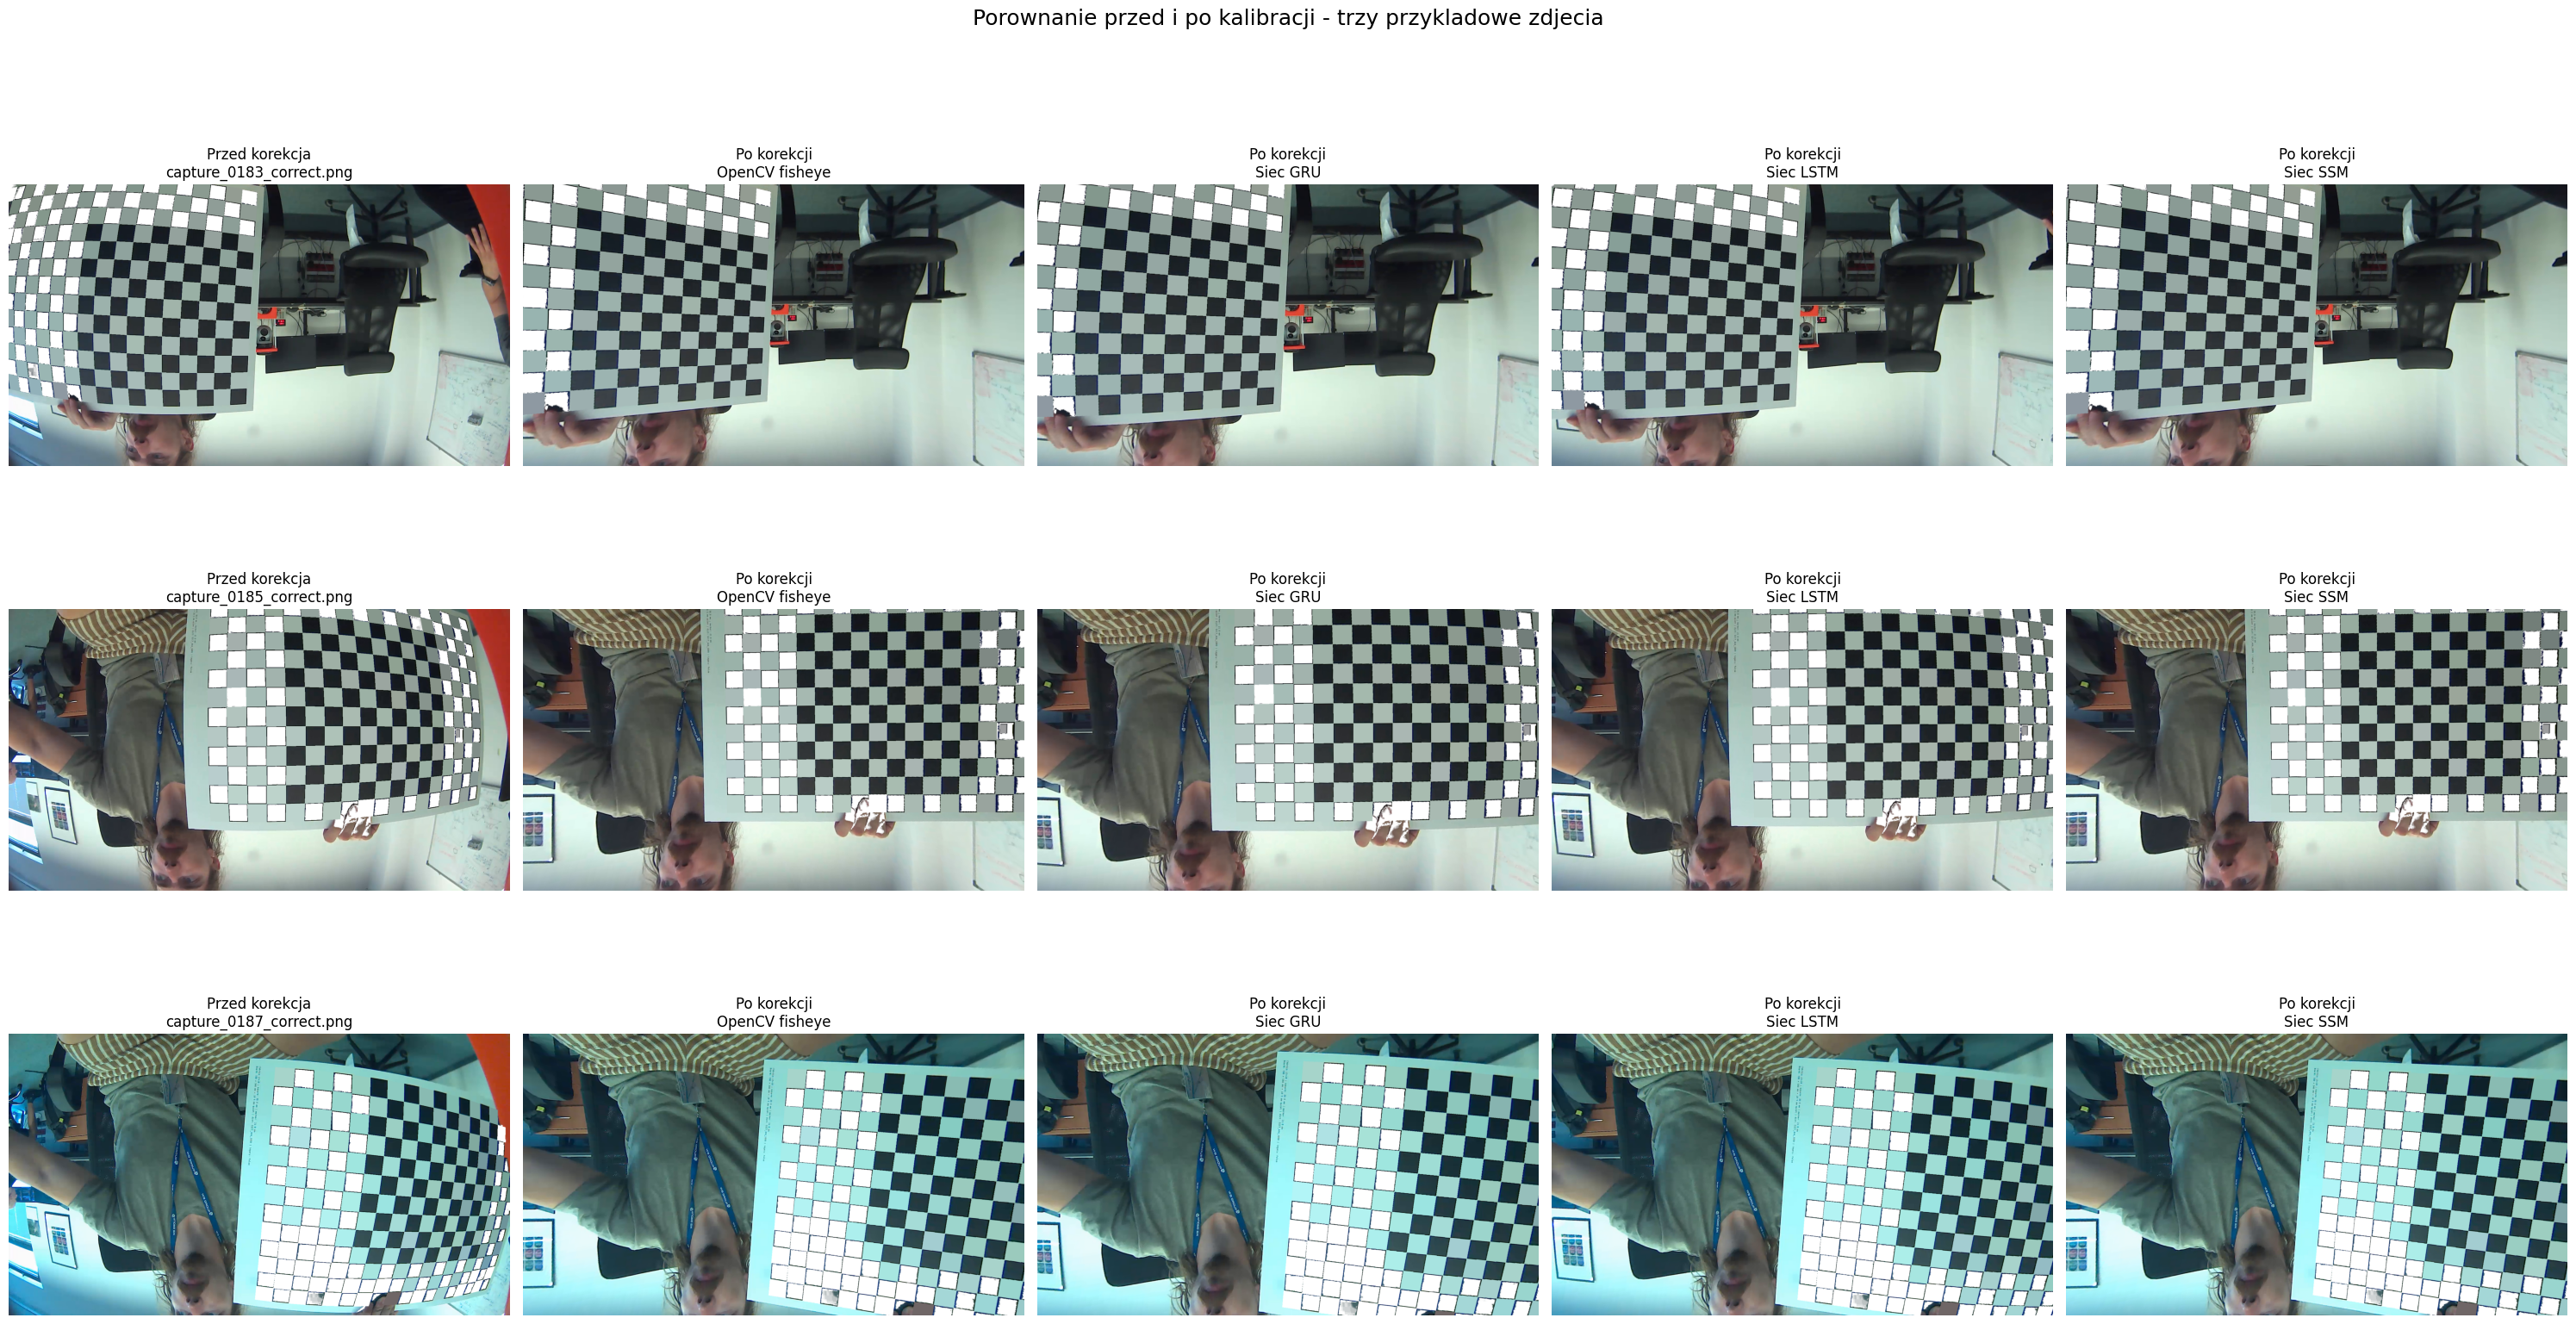

In [3]:
predictions = {}
for name, path in MODEL_CHECKPOINTS.items():
    model = load_model(path)
    with torch.no_grad():
        predictions[name] = model(network_input.cpu()).numpy()[0].astype(float)


def matrices(values):
    values = values.copy()
    w, h = image_size_calibration
    values[:4] *= [w, h, w, h]
    K = np.array([[values[0], 0, values[2]], [0, values[1], values[3]], [0, 0, 1]], float)
    return K, values[4:].reshape(4, 1)


methods = {'OpenCV fisheye': (camera_matrix, distortion_coefficients)}
methods.update({name: matrices(value) for name, value in predictions.items()})


def rmse(name, K, D):
    total = 0.0
    count = 0

    for obj, img in zip(object_points_all, image_points_all):
        # cv2.solvePnP interprets distCoeffs using the Brown-Conrady convention, not the
        # fisheye one, so K/D must never be passed to it directly regardless of the method.
        # Points are always undistorted first with the fisheye model, then solvePnP is run
        # with an identity camera and zero distortion.
        normalized = cv2.fisheye.undistortPoints(img, K, D)
        ok, r, t = cv2.solvePnP(
            obj.reshape(-1, 3), normalized.reshape(-1, 2), np.eye(3), None
        )

        if not ok:
            raise RuntimeError('Nie udalo sie wyznaczyc pozy planszy: ' + name)

        projected, _ = cv2.fisheye.projectPoints(obj, r, t, K, D)
        total += np.sum((img.reshape(-1, 2) - projected.reshape(-1, 2)) ** 2)
        count += len(img)

    return float(np.sqrt(total / count))


names = ['fx', 'fy', 'cx', 'cy', 'k1', 'k2', 'k3', 'k4']
rows = []
for name, (K, D) in methods.items():
    values = [K[0, 0], K[1, 1], K[0, 2], K[1, 2], *D.reshape(-1)]
    rows.append(
        {
            'metoda': name,
            **dict(zip(names, values)),
            'RMSE reprojekcji [px]': rmse(name, K, D),
        }
    )

all_methods_parameter_table = pd.DataFrame(rows)
print('Zestawienie wszystkich czterech metod')
display(
    all_methods_parameter_table.style.format(
        {**{n: '{:.8f}' for n in names}, 'RMSE reprojekcji [px]': '{:.6f}'}
    )
)

parameter_comparison_table = all_methods_parameter_table.set_index('metoda').T
parameter_comparison_table.insert(0, 'jednostka', ['px', 'px', 'px', 'px', '-', '-', '-', '-', 'px'])
print('Tabela parametrow: wiersze = parametry, kolumny = metody')
display(parameter_comparison_table.style.format('{:.8f}', subset=parameter_comparison_table.columns[1:]))

opencv_reference = all_methods_parameter_table.set_index('metoda').loc['OpenCV fisheye', names]
difference_rows = []
for method_name in all_methods_parameter_table['metoda']:
    method_values = all_methods_parameter_table.set_index('metoda').loc[method_name, names]
    difference_rows.append(
        {'metoda': method_name, **dict(zip(names, method_values - opencv_reference))}
    )

difference_table = pd.DataFrame(difference_rows).set_index('metoda')
print('Roznice parametrow wzgledem OpenCV fisheye (metoda - OpenCV)')
display(difference_table.style.format('{:+.8f}'))

example_paths = [p for p in image_paths_for_calibration if p.is_file()][:3]
if len(example_paths) < 3:
    raise RuntimeError('Potrzeba trzech zdjec przykladowych.')

fig, axes = plt.subplots(3, len(methods) + 1, figsize=(30, 17), squeeze=False)
for row, path in enumerate(example_paths):
    source = cv2.imread(str(path))
    axes[row, 0].imshow(cv2.cvtColor(source, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title('Przed korekcja\n' + path.name)

    for col, (name, (K, D)) in enumerate(methods.items(), 1):
        newK = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
            K, D, image_size_calibration, np.eye(3), balance=0.0, new_size=image_size_calibration
        )
        mx, my = cv2.fisheye.initUndistortRectifyMap(
            K, D, np.eye(3), newK, image_size_calibration, cv2.CV_32FC1
        )
        corrected = cv2.remap(
            source, mx, my, cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT
        )
        axes[row, col].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
        axes[row, col].set_title('Po korekcji\n' + name)

    for ax in axes[row]:
        ax.axis('off')

fig.suptitle('Porownanie przed i po kalibracji - trzy przykladowe zdjecia', fontsize=18)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

In [4]:
# Parametry kalibracji i predykcje modeli pozostaja wyznaczane na obrazach
# z characteristic_point. Ponizej porownania wizualne wykonywane sa natomiast
# dla niezaleznych zdjec z katalogu datasets.
comparison_images_dir = (
    PROJECT_ROOT / 'data/xfronter_calibration/datasets'
 )
comparison_output_dir = comparison_images_dir / 'undistortion_comparisons'
comparison_output_dir.mkdir(parents=True, exist_ok=True)

image_extensions = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
comparison_image_paths = sorted(
    path
    for path in comparison_images_dir.iterdir()
    if path.is_file() and path.suffix.lower() in image_extensions
 )
if not comparison_image_paths:
    raise FileNotFoundError(f'Brak obrazow do porownania w: {comparison_images_dir}')

saved_comparison_paths = []
skipped_image_paths = []
for image_path in comparison_image_paths:
    source_image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if source_image is None:
        skipped_image_paths.append((image_path, 'nie mozna wczytac obrazu'))
        continue

    source_height, source_width = source_image.shape[:2]
    source_image_size = (source_width, source_height)
    if source_image_size != image_size_calibration:
        skipped_image_paths.append(
            (
                image_path,
                f'rozmiar {source_image_size}, oczekiwano {image_size_calibration}',
            )
        )
        continue

    for method_name, (K, D) in methods.items():
        new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
            K,
            D,
            source_image_size,
            np.eye(3),
            balance=0.0,
            new_size=source_image_size,
        )
        map_x, map_y = cv2.fisheye.initUndistortRectifyMap(
            K,
            D,
            np.eye(3),
            new_K,
            source_image_size,
            cv2.CV_32FC1,
        )
        undistorted_image = cv2.remap(
            source_image,
            map_x,
            map_y,
            cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT,
        )

        safe_method_name = ''.join(
            character if character.isalnum() else '_' for character in method_name
        ).strip('_')
        output_path = comparison_output_dir / (
            f'{image_path.stem}_{safe_method_name}_comparison.png'
        )

        figure, axes = plt.subplots(1, 2, figsize=(20, 7))
        axes[0].imshow(cv2.cvtColor(source_image, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Przed undystorsja')
        axes[1].imshow(cv2.cvtColor(undistorted_image, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f'Po undystorsji - {method_name}')
        for axis in axes:
            axis.axis('off')
        figure.suptitle(f'{image_path.name} - {method_name}', fontsize=16)
        figure.tight_layout()
        figure.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.close(figure)

        saved_comparison_paths.append(output_path)
        print(f'{image_path.name} | {method_name}: {output_path}')

print(
    f'Zapisano {len(saved_comparison_paths)} porownan dla '
    f'{len(comparison_image_paths) - len(skipped_image_paths)} zdjec w: {comparison_output_dir}'
)
if skipped_image_paths:
    print('Pominiete zdjecia:')
    for image_path, reason in skipped_image_paths:
        print(f'- {image_path.name}: {reason}')

capture_0183.png | OpenCV fisheye: /home/dbabiarczyk/studia/semestr10/camera_calibration/data/xfronter_calibration/datasets/undistortion_comparisons/capture_0183_OpenCV_fisheye_comparison.png
capture_0183.png | Siec GRU: /home/dbabiarczyk/studia/semestr10/camera_calibration/data/xfronter_calibration/datasets/undistortion_comparisons/capture_0183_Siec_GRU_comparison.png
capture_0183.png | Siec LSTM: /home/dbabiarczyk/studia/semestr10/camera_calibration/data/xfronter_calibration/datasets/undistortion_comparisons/capture_0183_Siec_LSTM_comparison.png
capture_0183.png | Siec SSM: /home/dbabiarczyk/studia/semestr10/camera_calibration/data/xfronter_calibration/datasets/undistortion_comparisons/capture_0183_Siec_SSM_comparison.png
capture_0184.png | OpenCV fisheye: /home/dbabiarczyk/studia/semestr10/camera_calibration/data/xfronter_calibration/datasets/undistortion_comparisons/capture_0184_OpenCV_fisheye_comparison.png
capture_0184.png | Siec GRU: /home/dbabiarczyk/studia/semestr10/camera_cal